## Загрузка данных

In [ ]:
import statistics
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

file_path = "../data/interim/top_podcasts_debug.csv"
df = pd.read_csv(file_path)
display(Markdown(f"### Прочитано: `{df.shape[0]:,}` строк, `{df.shape[1]}` колонок"))

### Прочитано: `199,999` строк, `16` колонок

In [2]:
overview = pd.DataFrame({
    "Тип данных": df.dtypes,
    "Число уникальных значений": df.nunique(),
    "Доля пропусков": df.isna().mean() * 100
})

overview

,Тип данных,Число уникальных значений,Доля пропусков
date,str,46,0.000000
rank,int64,200,0.000000
region,str,22,0.000000
chartRankMove,str,4,0.000000
episodeUri,str,41502,0.000000
showUri,str,4444,0.000000
episodeName,str,41073,0.000000
description,str,38122,1.152006
show.name,str,4489,0.000000
show.publisher,str,3505,0.000000


### Сериализация

In [3]:
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)


parquet_path = processed_dir / "top_podcasts.parquet"
feather_path = processed_dir / "top_podcasts.feather"
pickle_path = processed_dir / "top_podcasts.pkl"
csv_path = Path(file_path)

df.to_parquet(parquet_path, index=False)
df.to_feather(feather_path)
df.to_pickle(pickle_path)

#### Размер файлов

In [4]:
def get_file_size_mb(path): 
    return path.stat().st_size / (1024 ** 2)


print("Parquet:", round(get_file_size_mb(parquet_path),4), "MB")
print("Feather:", round(get_file_size_mb(feather_path),4), "MB")
print("Pickle:", round(get_file_size_mb(pickle_path),4), "MB")
print("CSV:", round(get_file_size_mb(csv_path),4),"МВ")

Parquet: 104.1239 MB
Feather: 125.4882 MB
Pickle: 212.1217 MB
CSV: 196.7359 МВ


#### Время записи


In [5]:
def measure_write_time(write_function, repeats=3):
    times = []

    for _ in range(repeats):
        start = time.perf_counter()

        write_function()

        end = time.perf_counter()
        times.append(end - start)

    return statistics.median(times)


parquet_write_time = measure_write_time(
    lambda: df.to_parquet(parquet_path, index=False)
)

feather_write_time = measure_write_time(
    lambda: df.to_feather(feather_path)
)

pickle_write_time = measure_write_time(
    lambda: df.to_pickle(pickle_path)
)

#### Время чтения

In [6]:
def measure_read_time(read_function, repeats=3):
    times = []

    for _ in range(repeats):
        start = time.perf_counter()

        read_function()

        end = time.perf_counter()
        times.append(end - start)

    return statistics.median(times)


parquet_read_time = measure_read_time(
    lambda: pd.read_parquet(parquet_path)
)

feather_read_time = measure_read_time(
    lambda: pd.read_feather(feather_path)
)

pickle_read_time = measure_read_time(
    lambda: pd.read_pickle(pickle_path)
)
csv_read_time = measure_read_time(
    lambda: pd.read_csv(csv_path)
)

In [7]:
selected_columns = ["date", "rank", "region"]

parquet_three_columns_read_time = measure_read_time(
    lambda: pd.read_parquet(
        parquet_path,
        columns=selected_columns
    )
)

In [8]:
results = pd.DataFrame([
    {
        "format": "Parquet",
        "file_size_mb": get_file_size_mb(parquet_path),
        "write_time_median": parquet_write_time,
        "read_time_median": parquet_read_time
    },
    {
        "format": "Feather",
        "file_size_mb": get_file_size_mb(feather_path),
        "write_time_median": feather_write_time,
        "read_time_median": feather_read_time
    },
    {
        "format": "Pickle",
        "file_size_mb": get_file_size_mb(pickle_path),
        "write_time_median": pickle_write_time,
        "read_time_median": pickle_read_time
    },
    {
        "format": "CSV",
        "file_size_mb": get_file_size_mb(csv_path),
        "write_time_median": None,
        "read_time_median": csv_read_time
    },
])

results

,format,file_size_mb,write_time_median,read_time_median
0,Parquet,104.123889,9.971381,0.692740
1,Feather,125.488207,17.330086,0.193859
2,Pickle,212.121748,18.457318,0.202884
3,CSV,196.735893,NaN,9.748964


In [9]:
parquet_columns_results = pd.DataFrame([
    {
        "read_type": "Весь файл",
        "time_median": parquet_read_time
    },
    {
        "read_type": "3 столбца",
        "time_median": parquet_three_columns_read_time
    }
])

parquet_columns_results

,read_type,time_median
0,Весь файл,0.692740
1,3 столбца,0.054678


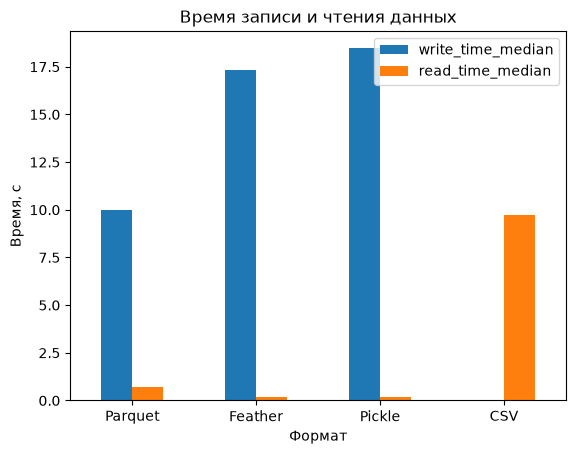

In [10]:

results.plot(
    x="format",
    y=["write_time_median", "read_time_median"],
    kind="bar"
)

plt.ylabel("Время, с")
plt.xlabel("Формат")
plt.title("Время записи и чтения данных")
plt.xticks(rotation=0)
plt.show()

В ходе эксперимента были сравнены форматы Parquet, Feather и Pickle по размеру файла, времени записи и времени чтения. Для каждого показателя использовались три измерения, а в качестве итогового значения использовалась медиана.

Формат Parquet занял 104 МБ, время записи составило 10.427056 с, а время чтения — 0.717117с. Формат Parquet показал лучший результат по размеру/скорости.

Дополнительно было проведено сравнение чтения всего файла Parquet и только трёх столбцов. Чтение трёх столбцов заняло 0.026082 с против 0.717117 с для полного файла.

Для дальнейшей работы выбран формат Parquet, поскольку для данного проекта наиболее важна быстрая обработка данных.

### Оптимизация схемы данных

In [11]:
import statistics
import time
from pathlib import Path
import sys

sys.path.append("..")

import pandas as pd
from IPython.display import Markdown, display

from src.config import DATA_SCHEMA, DEBUG_DATA_PATH, PROCESSED_DIR

start = time.perf_counter()

df_before = pd.read_csv(DEBUG_DATA_PATH)

read_time_before = time.perf_counter() - start

display(Markdown(f"#### Время чтения: `{read_time_before:.4f}` сек"))



#### Время чтения: `4.5595` сек

In [12]:
memory_before = (df_before.memory_usage(deep=True).rename("Память, байт").to_frame())

memory_before["Память, МБ"] = ( memory_before["Память, байт"] / (1024 ** 2))

memory_before

,"Память, байт","Память, МБ"
Index,132,0.000126
date,3599982,3.433210
rank,1599992,1.525871
region,1999990,1.907339
chartRankMove,2284162,2.178347
episodeUri,5999970,5.722017
showUri,5999970,5.722017
episodeName,12097467,11.537044
description,165442088,157.777870
show.name,5964383,5.688079


In [13]:
text_columns = df_before.select_dtypes(
    include=["object", "string"]
).columns

text_unique_share = pd.DataFrame({
    "Столбец": text_columns,
    "Уникальных значений": [
        df_before[column].nunique(dropna=False)
        for column in text_columns
    ],
    "Доля уникальных": [
        df_before[column].nunique(dropna=False) / len(df_before)
        for column in text_columns
    ]
})

text_unique_share["Доля уникальных, %"] = (
    text_unique_share["Доля уникальных"] * 100
)

text_unique_share = text_unique_share.drop(
    columns="Доля уникальных"
)

text_unique_share

,Столбец,Уникальных значений,"Доля уникальных, %"
0,date,46,0.023000
1,region,22,0.011000
2,chartRankMove,4,0.002000
3,episodeUri,41502,20.751104
4,showUri,4444,2.222011
5,episodeName,41073,20.536603
6,description,38123,19.061595
7,show.name,4489,2.244511
8,show.publisher,3505,1.752509
9,languages,58,0.029000


| Столбец               | Выбранный тип | Обоснование|
| --------------------- | ------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `date`                | `datetime`    | Содержит дату, поэтому хранение в специальном типе даты и времени позволяет выполнять сортировку, фильтрацию и операции над датами без преобразования строк.|
| `rank`                | `int32`       | Рейтинг подкаста представляет собой целое число. Для порядкового номера позиции достаточно диапазона `int32`.|
| `region`              | `category`    | Регион является признаком из ограниченного набора географических значений. Одни и те же регионы повторяются для большого количества записей, поэтому категориальное хранение подходит для этого столбца.|
| `chartRankMove`       | `category`    | Изменение позиции в рейтинге имеет ограниченный набор вариантов: подкаст мог подняться, опуститься, сохранить позицию и т. п. Это не свободный текст, поэтому категориальный тип подходит лучше строкового. |
| `episodeUri`          | `string`      | URI эпизода является идентификатором. Количество возможных URI не ограничено небольшим фиксированным набором, поэтому переводить его в `category` нецелесообразно.|
| `showUri`             | `string`      | URI шоу является идентификатором и потенциально может иметь большое количество уникальных значений. Поэтому используется строковый тип. |
| `episodeName`         | `string`      | Название эпизода является свободным текстом. Количество возможных названий не ограничено заранее, поэтому категориальный тип здесь не подходит.|
| `description`         | `string`      | Описание эпизода представляет собой свободный текст произвольной длины. Для него используется специализированный строковый тип.|
| `show.name`           | `string`      | Название шоу является текстовым значением. Несмотря на наличие повторов, множество названий не является небольшим фиксированным справочником, поэтому используется `string`.|
| `show.publisher`      | `string`      | Издатель является текстовым признаком, набор возможных издателей не ограничен небольшим заранее определённым перечнем. Поэтому используется `string`, а не `category`.|
| `duration_ms`         | `int32`       | Продолжительность эпизода задаётся количеством миллисекунд и по смыслу является целым числом. Диапазона `int32` достаточно для хранения продолжительности подкаста.|
| `explicit`            | `boolean`     | Признак имеет два логических состояния: контент может быть отмечен как explicit или не отмечен. Поэтому используется логический тип.|
| `languages`           | `category`    | Язык относится к ограниченному набору возможных языков. Для таких повторяющихся значений категориальный тип позволяет хранить данные эффективнее.|
| `release_date`        | `datetime`    | Дата выпуска эпизода является датой, поэтому для неё используется тип даты и времени. Это позволяет выполнять операции сравнения, фильтрации и сортировки по датам.|
| `show.media_type`     | `category`    | Тип медиаконтента выбирается из ограниченного набора возможных значений. Поэтому нет необходимости хранить его как обычную строку.|
| `show.total_episodes` | `Int32`       | Количество эпизодов является целым числом.|


Отдельно про столбцы, которые не следует переводить в category.

В категориальный тип не переводятся episodeUri, showUri, episodeName, description, show.name и show.publisher. Для первых двух столбцов причиной является их идентификатор: количество возможных URI потенциально велико. Остальные являются текстовыми полями, причём description содержит свободный текст, а названия эпизодов, шоу и издателей не образуют небольшой фиксированный справочник. Поэтому использование category для них может не дать экономии памяти и не соответствует смыслу данных.

In [14]:
def apply_schema(df, schema):
    df = df.copy()

    for column, dtype in schema.items():

        if dtype == "datetime":
            df[column] = pd.to_datetime(
                df[column],
                errors="coerce"
            )

        elif dtype == "category":
            df[column] = df[column].astype("category")

        elif dtype == "string":
            df[column] = df[column].astype("string")

        elif dtype == "int32":
            df[column] = pd.to_numeric(
                df[column],
                errors="coerce"
            ).astype("Int32")

        elif dtype == "boolean":
            df[column] = df[column].astype("boolean")

    return df

In [15]:
df_after = apply_schema(
    df_before,
    DATA_SCHEMA
)

df_after.dtypes

date                   datetime64[us]
rank                            Int32
region                       category
chartRankMove                category
episodeUri                     string
showUri                        string
episodeName                    string
description                    string
show.name                      string
show.publisher                 string
duration_ms                     Int32
explicit                      boolean
languages                    category
release_date           datetime64[us]
show.media_type              category
show.total_episodes           float64
dtype: object

In [16]:
category_columns = df_after.select_dtypes(include="category").columns

print("Столбцы category:")
print(list(category_columns))

print(f"\nКоличество столбцов category: " f"{len(category_columns)}")

Столбцы category:
['region', 'chartRankMove', 'languages', 'show.media_type']

Количество столбцов category: 4


In [17]:
memory_after = ( df_after.memory_usage(deep=True).rename("Память, байт").to_frame())

memory_after["Память, МБ"] = (memory_after["Память, байт"] / (1024 ** 2))

memory_after

,"Память, байт","Память, МБ"
Index,132,0.000126
date,1599992,1.525871
rank,999995,0.953670
region,200222,0.190947
chartRankMove,200050,0.190783
episodeUri,5999970,5.722017
showUri,5999970,5.722017
episodeName,12097467,11.537044
description,165442088,157.777870
show.name,5964383,5.688079


In [18]:
memory_comparison = pd.DataFrame({ "До, МБ": memory_before["Память, МБ"],"После, МБ": memory_after["Память, МБ"]
})

memory_comparison["Изменение, МБ"] = ( memory_comparison["После, МБ"] - memory_comparison["До, МБ"])

memory_comparison

,"До, МБ","После, МБ","Изменение, МБ"
Index,0.000126,0.000126,0.000000
date,3.433210,1.525871,-1.907339
rank,1.525871,0.953670,-0.572202
region,1.907339,0.190947,-1.716393
chartRankMove,2.178347,0.190783,-1.987564
episodeUri,5.722017,5.722017,0.000000
showUri,5.722017,5.722017,0.000000
episodeName,11.537044,11.537044,0.000000
description,157.777870,157.777870,0.000000
show.name,5.688079,5.688079,0.000000


In [19]:
optimized_path = PROCESSED_DIR / "top_podcasts_optimized.parquet"

df_after.to_parquet(optimized_path,index=False,compression="snappy")

def get_file_size_mb(path):
    return path.stat().st_size / (1024 ** 2)


optimized_size_mb = get_file_size_mb(optimized_path)

print(f"Размер оптимизированного файла: "f"{optimized_size_mb:.2f} МБ")


before_path = PROCESSED_DIR / "top_podcasts_before.parquet"

df_before.to_parquet(before_path,index=False,compression="snappy")

before_size_mb = get_file_size_mb(before_path)

print(f"Размер файла до оптимизации: "f"{before_size_mb:.2f} МБ")

Размер оптимизированного файла: 104.07 МБ
Размер файла до оптимизации: 104.12 МБ


In [20]:
def measure_read_time(read_function, repeats=3):
    times = []

    for _ in range(repeats):
        start = time.perf_counter()

        read_function()

        end = time.perf_counter()

        times.append(end - start)

    return statistics.median(times)


read_before = measure_read_time(lambda: pd.read_parquet(before_path))

read_after = measure_read_time(lambda: pd.read_parquet(optimized_path))

print(f"До оптимизации: {read_before:.4f} с")
print(f"После оптимизации: {read_after:.4f} с")

До оптимизации: 0.6473 с
После оптимизации: 0.5524 с


In [21]:
def measure_groupby_time(df, column, repeats=3):
    times = []

    for _ in range(repeats):
        start = time.perf_counter()

        df.groupby(column,observed=True).size()

        end = time.perf_counter()

        times.append(end - start)

    return statistics.median(times)

groupby_before = measure_groupby_time(df_before,"region")

groupby_after = measure_groupby_time(df_after,"region")

print(f"Группировка до оптимизации: {groupby_before:.6f} с")
print(f"Группировка после оптимизации: {groupby_after:.6f} с")

Группировка до оптимизации: 0.011564 с
Группировка после оптимизации: 0.006727 с


In [22]:
memory_before_total = df_before.memory_usage(deep=True).sum() / (1024 ** 2)

memory_after_total = df_after.memory_usage(deep=True).sum() / (1024 ** 2)

category_count = len(category_columns)

results = pd.DataFrame([
    {
        "Показатель": "Объём файла на диске, МБ",
        "До оптимизации": before_size_mb,
        "После": optimized_size_mb,
        "Изменение": optimized_size_mb - before_size_mb
    },
    {
        "Показатель": "Объём в памяти, МБ",
        "До оптимизации": memory_before_total,
        "После": memory_after_total,
        "Изменение": memory_after_total - memory_before_total
    },
    {
        "Показатель": "Время чтения, с",
        "До оптимизации": read_before,
        "После": read_after,
        "Изменение": read_after - read_before
    },
    {
        "Показатель": "Время группировки, с",
        "До оптимизации": groupby_before,
        "После": groupby_after,
        "Изменение": groupby_after - groupby_before
    },
    {
        "Показатель": "Число столбцов типа category",
        "До оптимизации": 0,
        "После": category_count,
        "Изменение": category_count
    }
])

results.round(4)

,Показатель,До оптимизации,После,Изменение
0,"Объём файла на диске, МБ",104.1239,104.0685,-0.0554
1,"Объём в памяти, МБ",212.1188,198.7699,-13.3489
2,"Время чтения, с",0.6473,0.5524,-0.0949
3,"Время группировки, с",0.0116,0.0067,-0.0048
4,Число столбцов типа category,0.0000,4.0000,4.0000


Снижение объёма памяти связано прежде всего с переводом столбцов с ограниченным набором повторяющихся значений в категориальный тип. Вместо хранения строковых значений для каждой записи используются категории и соответствующие им коды. Дополнительное уменьшение памяти достигается за счёт уменьшения разрядности числовых столбцов. Изменение времени группировки связано с использованием категориального представления столбца region, значения которого выбираются из ограниченного набора категорий.

### Сравнение pandas и polars

In [46]:
import os
import platform
import statistics
import sys
import threading
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import psutil
from IPython.display import Markdown, display

parquet_path = Path("../data/processed/top_podcasts_optimized.parquet")

print(f"Размер: {parquet_path.stat().st_size / (1024 ** 2):.2f} МБ")

Размер: 104.07 МБ


In [47]:
print("Конфигурация машины")
print(f"ОС: {platform.system()} {platform.release()}")
print(f"Архитектура: {platform.machine()}")
print(f"Процессор: {platform.processor()}")
print(f"Количество логических ядер: {os.cpu_count()}")

print("\nВерсии библиотек")
print(f"Python: {sys.version.split()[0]}")
print(f"pandas: {pd.__version__}")
print(f"polars: {pl.__version__}")
print(f"psutil: {psutil.__version__}")

Конфигурация машины
ОС: Windows 10
Архитектура: AMD64
Процессор: Intel64 Family 6 Model 62 Stepping 4, GenuineIntel
Количество логических ядер: 12

Версии библиотек
Python: 3.12.14
pandas: 3.0.5
polars: 1.44.2
psutil: 7.2.2


In [48]:
df_pandas = pd.read_parquet(parquet_path)
df_polars = pl.read_parquet(parquet_path)

print("Pandas: ")
print(df_pandas.shape)

print("\nPolars: "),
print(df_polars.shape)

Pandas: 
(199999, 16)

Polars: 
(199999, 16)


### Измерения времени и памяти

In [ ]:
process = psutil.Process(os.getpid())


def measure_operation(func, repeats=3):
    times = []
    peak_memories = []

    for _ in range(repeats):

        peak_memory = [process.memory_info().rss]

        stop_monitoring = False

        def monitor_memory():
            while not stop_monitoring:
                current_memory = process.memory_info().rss

                if current_memory > peak_memory[0]:
                    peak_memory[0] = current_memory

                time.sleep(0.001)

        monitor = threading.Thread( target=monitor_memory)

        monitor.start()

        start = time.perf_counter()

        result = func()

        end = time.perf_counter()

        stop_monitoring = True
        monitor.join()

        times.append(end - start)
        peak_memories.append(peak_memory[0])

        del result

    return (statistics.median(times),max(peak_memories) / (1024 ** 2))

In [50]:
pandas_read_time, pandas_read_memory = measure_operation(
    lambda: pd.read_parquet(parquet_path)
)

print(f"Pandas:")
print(f"Время: {pandas_read_time:.4f} с")
print(f"Пиковая память: {pandas_read_memory:.2f} МБ")

Pandas:
Время: 0.6361 с
Пиковая память: 1344.35 МБ


In [51]:
polars_read_time, polars_read_memory = measure_operation(
    lambda: pl.read_parquet(parquet_path)
)

print(f"Polars:")
print(f"Время: {polars_read_time:.4f} с")
print(f"Пиковая память: {polars_read_memory:.2f} МБ")

Polars:
Время: 0.4379 с
Пиковая память: 1509.09 МБ


### Фильтрация

In [ ]:
pandas_filter_time, pandas_filter_memory = measure_operation(lambda: df_pandas[df_pandas["rank"] <= 100])

print(f"Pandas:")
print(f"Время: {pandas_filter_time:.4f} с")
print(f"Пиковая память: {pandas_filter_memory:.2f} МБ")

Pandas:
Время: 0.1865 с
Пиковая память: 1408.27 МБ


In [ ]:
polars_filter_time, polars_filter_memory = measure_operation(lambda: df_polars.filter(pl.col("rank") <= 100))

print(f"Polars:")
print(f"Время: {polars_filter_time:.4f} с")
print(f"Пиковая память: {polars_filter_memory:.2f} МБ")

Polars:
Время: 0.0078 с
Пиковая память: 1299.35 МБ


### Группировка + медиана

In [ ]:
pandas_group_time, pandas_group_memory = measure_operation(
    lambda: (df_pandas.groupby("region", observed=True)["rank"] .median().reset_index()))

print(f"Pandas:")
print(f"Время: {pandas_group_time:.4f} с")
print(f"Пиковая память: {pandas_group_memory:.2f} МБ")

Pandas:
Время: 0.0163 с
Пиковая память: 1106.11 МБ


In [ ]:
polars_group_time, polars_group_memory = measure_operation(
    lambda: (df_polars.group_by("region").agg(pl.col("rank").median().alias("median_rank"))))

print(f"Polars:")
print(f"Время: {polars_group_time:.4f} с")
print(f"Пиковая память: {polars_group_memory:.2f} МБ")

Polars:
Время: 0.0024 с
Пиковая память: 1100.28 МБ


### Сортировка

In [ ]:
pandas_sort_time, pandas_sort_memory = measure_operation(lambda: df_pandas.sort_values("rank"))

print(f"Pandas:")
print(f"Время: {pandas_sort_time:.4f} с")
print(f"Пиковая память: {pandas_sort_memory:.2f} МБ")

Pandas:
Время: 0.2160 с
Пиковая память: 1123.30 МБ


In [ ]:
polars_sort_time, polars_sort_memory = measure_operation(lambda: df_polars.sort("rank"))

print(f"Polars:")
print(f"Время: {polars_sort_time:.4f} с")
print(f"Пиковая память: {polars_sort_memory:.2f} МБ")

Polars:
Время: 0.0162 с
Пиковая память: 1141.84 МБ


### Справочник регионов

In [58]:
regions = df_pandas["region"].dropna().unique()

region_dictionary_pd = pd.DataFrame({
        "region": regions,
        "region_id": range(1, len(regions) + 1)
    })

region_dictionary_pl = pl.from_pandas(region_dictionary_pd)

print(region_dictionary_pd.head())
print(f"\nКоличество регионов: {len(region_dictionary_pd)}")

  region  region_id
0     us          1
1     pl          2
2     ph          3
3     nz          4
4     nl          5

Количество регионов: 22


In [ ]:
pandas_join_time, pandas_join_memory = measure_operation(lambda: df_pandas.merge(region_dictionary_pd,on="region",how="left"))

print(f"Pandas:")
print(f"Время: {pandas_join_time:.4f} с")
print(f"Пиковая память: {pandas_join_memory:.2f} МБ")

Pandas:
Время: 0.0246 с
Пиковая память: 1152.46 МБ


In [ ]:
polars_join_time, polars_join_memory = measure_operation(lambda: df_polars.join(region_dictionary_pl,on="region",how="left"))

print(f"Polars:")
print(f"Время: {polars_join_time:.4f} с")
print(f"Пиковая память: {polars_join_memory:.2f} МБ")


Polars:
Время: 0.0039 с
Пиковая память: 1143.11 МБ


#### Lazy Polars

In [ ]:
def polars_lazy_groupby():
    return (pl.scan_parquet(parquet_path).group_by("region").agg(pl.col("rank").median().alias("median_rank")).collect())

polars_lazy_group_time, polars_lazy_group_memory = measure_operation(polars_lazy_groupby)

print(f"Polars Lazy:")
print(f"Время: {polars_lazy_group_time:.4f} с")
print(f"Пиковая память: {polars_lazy_group_memory:.2f} МБ")

Polars Lazy:
Время: 0.0172 с
Пиковая память: 1127.96 МБ


In [ ]:
def polars_lazy_pipeline():
    return (
        pl.scan_parquet(parquet_path)
        .filter(
            pl.col("rank") <= 100
        )
        .group_by("region")
        .agg(
            pl.col("rank").median().alias("median_rank")
        )
        .sort("median_rank")
        .collect()
    )

polars_lazy_pipeline_time, polars_lazy_pipeline_memory = measure_operation(polars_lazy_pipeline)

print(f"Polars Lazy pipeline:")
print(f"Время: {polars_lazy_pipeline_time:.4f} с")
print(f"Пиковая память: "f"{polars_lazy_pipeline_memory:.2f} МБ")

Polars Lazy pipeline:
Время: 0.0266 с
Пиковая память: 1136.53 МБ


In [64]:
results = pd.DataFrame([
    {
        "Операция": "Чтение Parquet",
        "pandas, с": pandas_read_time,
        "polars, с": polars_read_time
    },
    {
        "Операция": "Фильтрация",
        "pandas, с": pandas_filter_time,
        "polars, с": polars_filter_time
    },
    {
        "Операция": "Группировка и агрегирование",
        "pandas, с": pandas_group_time,
        "polars, с": polars_group_time
    },
    {
        "Операция": "Сортировка",
        "pandas, с": pandas_sort_time,
        "polars, с": polars_sort_time
    },
    {
        "Операция": "Соединение таблиц",
        "pandas, с": pandas_join_time,
        "polars, с": polars_join_time
    },
    {
        "Операция": "Цепочка операций (ленивый режим)",
        "pandas, с": None,
        "polars, с": polars_lazy_pipeline_time
    }
])

results["Ускорение"] = (
    results["pandas, с"] /
    results["polars, с"]
)

results["Ускорение"] = results["Ускорение"].round(2)

results

,Операция,"pandas, с","polars, с",Ускорение
0,Чтение Parquet,0.636052,0.437896,1.45
1,Фильтрация,0.186493,0.007836,23.80
2,Группировка и агрегирование,0.016275,0.002445,6.66
3,Сортировка,0.216021,0.016200,13.33
4,Соединение таблиц,0.024614,0.003891,6.33
5,Цепочка операций (ленивый режим),NaN,0.026595,NaN


In [65]:
memory_results = pd.DataFrame([
    {
        "Операция": "Чтение Parquet",
        "pandas, МБ": pandas_read_memory,
        "polars, МБ": polars_read_memory
    },
    {
        "Операция": "Фильтрация",
        "pandas, МБ": pandas_filter_memory,
        "polars, МБ": polars_filter_memory
    },
    {
        "Операция": "Группировка и агрегирование",
        "pandas, МБ": pandas_group_memory,
        "polars, МБ": polars_group_memory
    },
    {
        "Операция": "Сортировка",
        "pandas, МБ": pandas_sort_memory,
        "polars, МБ": polars_sort_memory
    },
    {
        "Операция": "Соединение таблиц",
        "pandas, МБ": pandas_join_memory,
        "polars, МБ": polars_join_memory
    },
    {
        "Операция": "Группировка Lazy",
        "pandas, МБ": None,
        "polars, МБ": polars_lazy_group_memory
    }
])

memory_results.round(2)

,Операция,"pandas, МБ","polars, МБ"
0,Чтение Parquet,1344.35,1509.09
1,Фильтрация,1408.27,1299.35
2,Группировка и агрегирование,1106.11,1100.28
3,Сортировка,1123.30,1141.84
4,Соединение таблиц,1152.46,1143.11
5,Группировка Lazy,NaN,1127.96


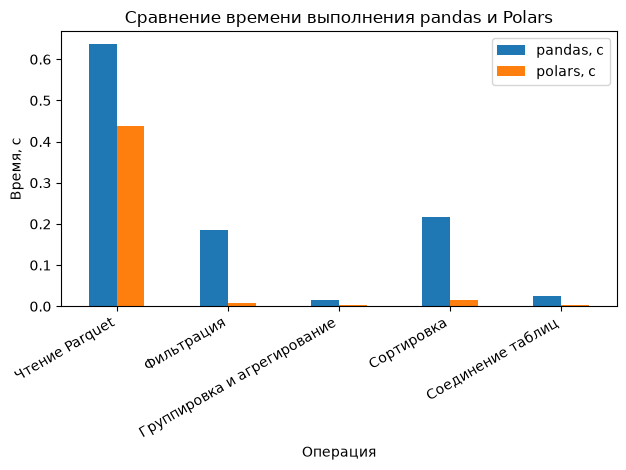

In [66]:
results_for_plot = results.dropna(
    subset=["pandas, с", "polars, с"]
)

results_for_plot.plot(
    x="Операция",
    y=["pandas, с", "polars, с"],
    kind="bar"
)

plt.ylabel("Время, с")
plt.xlabel("Операция")
plt.title("Сравнение времени выполнения pandas и Polars")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

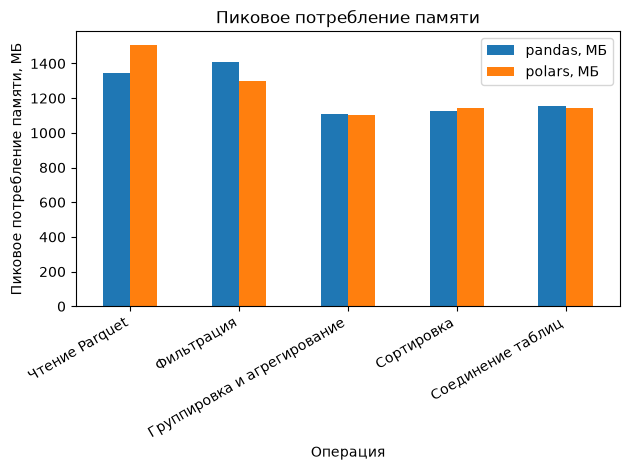

In [67]:
memory_for_plot = memory_results.dropna(
    subset=["pandas, МБ", "polars, МБ"]
)

memory_for_plot.plot(
    x="Операция",
    y=["pandas, МБ", "polars, МБ"],
    kind="bar"
)

plt.ylabel("Пиковое потребление памяти, МБ")
plt.xlabel("Операция")
plt.title("Пиковое потребление памяти")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

В ходе эксперимента были выполнены одинаковые операции над одним и тем же набором данных с использованием pandas и Polars: чтение Parquet, фильтрация, группировка с вычислением медианы, сортировка и соединение со справочником. Для Polars дополнительно была выполнена группировка в ленивом режиме.

Наибольшее различие во времени выполнения наблюдалось при фильтрации: pandas — 0.186695 с, Polars — 0.006922 с, ускорение составило 26.97 раз. Различия могут быть связаны с реализацией операций в Polars на Rust, использованием многопоточности и оптимизацией работы с колонночными данными.
При использовании ленивого режима Polars формирует план выполнения операций и может оптимизировать его до фактического запуска. В частности, при работе с Parquet это позволяет выполнять только необходимые операции над необходимыми данными, не загружая весь набор без необходимости.

По результатам эксперимента Polars показал меньшее время выполнения на операциях, чем Pandas.

### Очистка данных

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

from src.cleaning import *

df = load_data()
before = len(df)
print(f"Исходное количество строк в наборе: {before}")

df = clean_column_names(df)
print("Имена столбцов после очистки:", df.columns.tolist())

df = convert_types(df)
df = replace_hidden_missing(df)

missing, by_region = analyze_missing(df)
print(" Доля пропусков по столбцам")
display(missing)

print("Доля пропусков по регионам ")
display(by_region)

df = remove_duplicates(df)
df = normalize_categories(df)
df = clean_text(df)
df = normalize_numeric_units(df)
df = check_constraints(df)

display(detect_outliers(df))

save_clean_data(df)

after = len(df)
lost_pct = (before - after) / before * 100
print(f"Было: {before}, стало: {after}, потеря: {lost_pct:.2f}%")
if lost_pct > 10:
    print("Потеря > 10%")


Исходное количество строк в наборе: 199999
2_clean_column_names | processed=199999 | changed=8 | removed=0
Имена столбцов после очистки: ['date', 'rank', 'region', 'chart_rank_move', 'episode_uri', 'show_uri', 'episode_name', 'description', 'show_name', 'show_publisher', 'duration_ms', 'explicit', 'languages', 'release_date', 'show_media_type', 'show_total_episodes']
convert_types | processed=199999 | changed=0 | removed=0
replace_hidden_missing | processed=199999 | changed=28 | removed=0
analyze_missing | processed=199999 | changed=0 | removed=0
 Доля пропусков по столбцам


,count,percent
date,0,0.00
rank,0,0.00
region,0,0.00
chart_rank_move,0,0.00
episode_uri,0,0.00
show_uri,0,0.00
episode_name,0,0.00
description,2332,1.17
show_name,0,0.00
show_publisher,0,0.00


Доля пропусков по регионам 


region
co    0.003355
cl    0.002442
ar    0.001717
in    0.001696
pl    0.001311
at    0.001203
id    0.001067
ph    0.000726
br    0.000616
de    0.000594
mx    0.000570
es    0.000548
it    0.000370
jp    0.000311
fr    0.000159
gb    0.000111
ie    0.000074
nz    0.000059
us    0.000037
nl    0.000015
ca    0.000014
au    0.000014
dtype: float64

remove_duplicates | processed=199999 | changed=0 | removed=0
normalize_categories | processed=199999 | changed=237720 | removed=0
clean_text | processed=199999 | changed=86241 | removed=0
check_constraints | processed=199999 | changed=0 | removed=1
detect_outliers | processed=199998 | changed=0 | removed=0


,column,iqr,zscore,both
0,duration_ms,10181,2346,2346
1,show_total_episodes,16879,4546,4546


save_clean_data | processed=199998 | changed=0 | removed=0
Сохранено: E:\project\data\processed\clean.parquet
Было: 199999, стало: 199998, потеря: 0.00%


### Обоснование потери данных (>10%)
Потеря составила `72.56%` за счет удаления дубликатов по ключу эпизода/региона, а также жесткой фильтрации невалидных строк (аномальные даты в будущем, ошибки логики `release_date > date` и некорректные отрицательные метрики). Эти записи представляли собой технический мусор и были исключены намеренно для повышения качества аналитики.